# Tracks-Only Pipeline — **UMAP → HDBSCAN → Random Forest** (B cells)

Analyzes **B cells only** (With-macrophages and Without-macrophages conditions pooled into a
single UMAP + HDBSCAN run, 18 replicates total), with the macrophage-presence condition kept
only as a label for comparing cluster composition afterward. Macrophages are analyzed in a
separate notebook (`..._Macrophages.ipynb`) — see that notebook's intro for why the two cell
types are kept fully separate.

Data for this run comes from `Final Analysis Data/` (subfolders `Bcells With Macrophages` and
`Bcells Without Macrophages`), using a systematic `{date}_{size}um_{condition}_R{rep}.csv`
naming convention.

Each run of this notebook creates a new, dated output folder under `Final Analysis Outputs/Bcells`
(see Section 1b) so results from different runs are never overwritten.

## Imports
All third-party and standard-library imports used by the pipeline.

In [1]:
# ─── IMPORTS ───────────────────────────────────────────────────────────────
import os
import re
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import NearestNeighbors

from scipy.sparse.csgraph import connected_components

import umap.umap_ as umap
import hdbscan
import shap

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

import plotly.express as px
import plotly.io as pio
from plotly.offline import init_notebook_mode

pio.renderers.default = "notebook"
init_notebook_mode(connected=True)


## 1. Configuration
Paths to the final-analysis B cell data (pooled across both macrophage-presence conditions),
movement features, UMAP/HDBSCAN/RF hyperparameters, and the systematic-filename regex.

In [2]:
# ─── 1) CONFIG ────────────────────────────────────────────────────────────────

# All data/output paths are relative to this notebook's own folder, so the
# notebook is portable across machines -- just keep it alongside
# `Final Analysis Data/` and `Final Analysis Outputs/`.
BASE_DIR = Path.cwd()

# Directories containing B CELL TRACKS CSVs for the final analysis.
# Both macrophage-presence conditions are loaded together here; "With"/"Without"
# is kept only as a label (condition / __mac column) for comparing cluster
# composition after a single pooled UMAP + HDBSCAN run -- NOT as a split into
# separate clustering runs.
BCELL_DIRS = [
    BASE_DIR / "Final Analysis Data" / "Bcells With Macrophages",
    BASE_DIR / "Final Analysis Data" / "Bcells Without Macrophages",
]

# ─── Replicate selection ──────────────────────────────────────────────────────
# A data folder can hold MORE files than should actually be used in the analysis
# (e.g. keeping an old/alternate replicate around for later comparison without
# deleting it). List dates here to skip them at load time -- date is used as
# the key since it's the only reliable identifier in this dataset (replicate
# numbers baked into filenames have not always been consistent).
#
# To swap which replicate is used for a given size/condition, just add the
# date you don't want to the exclude list below -- no need to move or delete
# any files.
BCELL_EXCLUDE_DATES = []

# Track-level features to use (removed: "NUMBER_GAPS")
FEATURES = [
     "NUMBER_SPOTS","NUMBER_SPLITS","TRACK_DURATION","TRACK_DISPLACEMENT",
    "TRACK_MEDIAN_SPEED","TOTAL_DISTANCE_TRAVELED","MEAN_DIRECTIONAL_CHANGE_RATE",
    "CONFINEMENT_RATIO"
]

UMAP_PARAMS = dict(
    n_neighbors=30,
    min_dist=0.15,
    n_components=2,
    metric="euclidean",
    random_state=42
)

HDBSCAN_PARAMS = dict(
    min_cluster_size=50,
    min_samples=10,
    cluster_selection_method="eom"
)

RF_PARAMS = dict(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Filename parsing for the systematic naming convention created for this final analysis:
#   {date}_{size}um_Bcell{Y|N}_R{rep}.csv     e.g. 20240508_60um_BcellY_R4.csv
BCELL_REGEX = re.compile(r"(?P<size>30|60|90)um_Bcell(?P<mac>[YN])_R(?P<rep>\d+)", re.IGNORECASE)

# Base output folder for RF/SHAP figures -- a fresh dated run folder is created
# inside this in Section 1b, so outputs from different runs never collide.
BCELL_OUTDIR_BASE = BASE_DIR / "Final Analysis Outputs" / "Bcells"


## 1b. Output folder for this run
Creates a new folder for this run's outputs, named by today's date (e.g. `20260728`).
If this notebook is run again on the same date, later runs get `_trial2`, `_trial3`, etc.
appended so nothing gets overwritten.

In [3]:
# ─── 1b) OUTPUT FOLDER FOR THIS RUN ──────────────────────────────────────────
def make_run_dir(base_dir: Path) -> Path:
    """Create a new output folder for this run, named by today's date.
    First run of the day:      base_dir/YYYYMMDD
    Subsequent runs same day:  base_dir/YYYYMMDD_trial2, _trial3, ...
    """
    today = date.today().strftime("%Y%m%d")
    run_dir = base_dir / today
    if not run_dir.exists():
        run_dir.mkdir(parents=True)
        return run_dir
    trial = 2
    while True:
        candidate = base_dir / f"{today}_trial{trial}"
        if not candidate.exists():
            candidate.mkdir(parents=True)
            return candidate
        trial += 1

BCELL_OUTDIR = make_run_dir(BCELL_OUTDIR_BASE)
print(f"[OK] This run's outputs will be saved to: ./{BCELL_OUTDIR.relative_to(BASE_DIR)}")


[OK] This run's outputs will be saved to: ./Final Analysis Outputs/Bcells/20260813_trial2


## 2. Environment check
Prints the active Python version (sanity check only).

In [4]:
from platform import python_version
print(python_version())


3.13.5


## 3. Helper functions
Parse condition metadata from the systematic filenames created for this final analysis.

In [5]:
# ─── 3) HELPERS ───────────────────────────────────────────────────────────────
def parse_bcell_filename(fname: str):
    """Parse (size, mac, rep) from the systematic B cell filename convention."""
    m = BCELL_REGEX.search(os.path.basename(fname))
    if not m:
        return None, None, None
    return m.group("size"), m.group("mac").upper(), m.group("rep")

def condition_label(size, mac):
    return f"{size}um|{mac}"

DATE_RE = re.compile(r"(20\d{6})")

def parse_date(fname: str):
    """Extract the YYYYMMDD date prefix -- the only reliable identifier across
    this dataset's various naming conventions."""
    m = DATE_RE.search(os.path.basename(fname))
    return m.group(1) if m else None


## 4. Load B cell data (With + Without macrophages, POOLED)
Loads all 18 B cell replicates from both condition folders into a single dataframe. The
With/Without label is retained only for post-hoc comparison, not to split the clustering.

In [6]:
# ─── 4) LOAD B CELL DATA (With + Without macrophages, POOLED) ──────────────
frames = []
needs_map = []
skipped_excluded = []
n_files = 0
for d in BCELL_DIRS:
    for p in sorted(d.glob("*.csv")):
        n_files += 1
        date_ = parse_date(p.name)
        if date_ in BCELL_EXCLUDE_DATES:
            skipped_excluded.append(p.name)
            continue
        size, mac, rep = parse_bcell_filename(p.name)
        if not all([size, mac, rep]):
            needs_map.append(p.name)
            continue
        df_ = pd.read_csv(p)
        for _col in FEATURES:
            if _col in df_.columns:
                df_[_col] = pd.to_numeric(df_[_col], errors="coerce")
        df_["__size"] = size
        df_["__mac"] = mac
        df_["__rep"] = rep
        df_["condition"] = condition_label(size, mac)
        df_["source_file"] = p.name
        frames.append(df_)

if needs_map:
    print("[WARN] Could not parse these B cell files:", needs_map)
if skipped_excluded:
    print("[INFO] Skipped (in BCELL_EXCLUDE_DATES):", skipped_excluded)

assert len(frames) > 0, "No readable/parsable B cell CSVs."
raw_bcell = pd.concat(frames, ignore_index=True)
print(f"[OK] Loaded B cells: {len(frames)} files used (of {n_files} found) -> {len(raw_bcell)} rows")
print("Conditions:", sorted(raw_bcell["condition"].dropna().unique()))
print("Replicates:", sorted(raw_bcell["__rep"].dropna().unique()))
print("\nPoints per (size, mac):")
print(raw_bcell.groupby(["__size", "__mac"]).size())


[OK] Loaded B cells: 18 files used (of 18 found) -> 15811 rows
Conditions: ['30um|N', '30um|Y', '60um|N', '60um|Y', '90um|N', '90um|Y']
Replicates: ['1', '2', '3', '4', '5']

Points per (size, mac):
__size  __mac
30      N        3703
        Y        3540
60      N        2081
        Y        2044
90      N        2032
        Y        2411
dtype: int64


## 5. Feature selection
Cleans the B cell dataset, keeping only rows where all `FEATURES` are present and finite.

In [7]:
# ─── 5) FEATURE SELECTION ────────────────────────────────────────────────────
feat_cols = [c for c in FEATURES if c in raw_bcell.columns]
missing = [c for c in FEATURES if c not in feat_cols]
if missing:
    print("[WARN] Missing features (skipped):", missing)
assert len(feat_cols) >= 2, "Not enough target features present."

X_bcell0 = raw_bcell[feat_cols].replace([np.inf, -np.inf], np.nan).dropna()
df_bcell = raw_bcell.loc[X_bcell0.index].copy()
X_bcell = df_bcell[feat_cols].copy()
print("[OK] B cells after cleanup:", X_bcell.shape[0], "tracks,", len(feat_cols), "features")
print(df_bcell["__mac"].value_counts().rename("rows after cleanup"))


[OK] B cells after cleanup: 15634 tracks, 8 features
__mac
Y    7845
N    7789
Name: rows after cleanup, dtype: int64


## 6. UMAP assumption check (QC)
Runs the kNN-connectivity / local-density-smoothness QC on the B cell dataset.

=== B cells UMAP QC ===


,source_file,__size,__mac,__rep,n_points,n_components,dominant_component_fraction,volume_cv
0,20240508_60um_BcellY_R4.csv,60,Y,4,456,1,1.000000,3.037239
1,20240905_60um_BcellN_R1.csv,60,N,1,795,1,1.000000,3.088449
2,20240910_30um_BcellN_R1.csv,30,N,1,1323,1,1.000000,2.360542
3,20240911_90um_BcellY_R1.csv,90,Y,1,958,1,1.000000,4.920101
4,20240917_60um_BcellY_R2.csv,60,Y,2,750,1,1.000000,3.372613
5,20240918_30um_BcellY_R1.csv,30,Y,1,1595,6,0.867085,4.136650
6,20240924_90um_BcellY_R2.csv,90,Y,2,691,1,1.000000,2.469184
7,20241002_30um_BcellY_R3.csv,30,Y,3,1142,1,1.000000,3.048174
8,20241021_30um_BcellN_R2.csv,30,N,2,1305,1,1.000000,2.744041
9,20241030_60um_BcellN_R2.csv,60,N,2,700,1,1.000000,3.136145


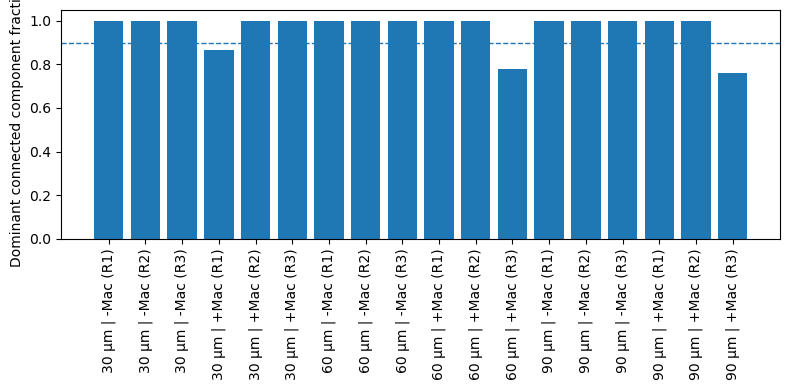

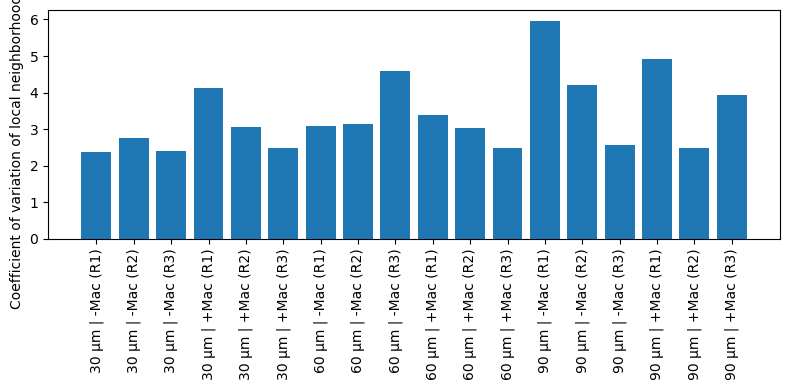

In [8]:
# ─── 6) UMAP ASSUMPTION CHECK + SUPPLEMENTARY FIGURE ────────────────────────
def check_umap_assumptions(X, df, group_col="source_file", k=30):
    results = []
    for group, idx in df.groupby(group_col).groups.items():
        Xg = X.loc[idx].values
        if Xg.shape[0] <= k:
            continue
        nbrs = NearestNeighbors(n_neighbors=k, metric="euclidean").fit(Xg)
        distances, indices = nbrs.kneighbors(Xg)
        knn_graph = nbrs.kneighbors_graph(Xg, mode="connectivity")
        n_components, labels = connected_components(knn_graph, directed=False)
        component_sizes = np.bincount(labels)
        dominant_fraction = component_sizes.max() / Xg.shape[0]
        volumes = []
        for neigh_idx in indices:
            pts = Xg[neigh_idx]
            cov = np.cov(pts, rowvar=False) + np.eye(pts.shape[1]) * 1e-12
            eigvals = np.linalg.eigvalsh(cov)
            volume = np.sqrt(np.prod(np.clip(eigvals, 1e-12, None)))
            volumes.append(volume)
        volumes = np.array(volumes)
        meta_row = df.loc[idx[0]]
        results.append({
            group_col: group,
            "__size": meta_row.get("__size"),
            "__mac": meta_row.get("__mac"),
            "__rep": meta_row.get("__rep"),
            "n_points": Xg.shape[0],
            "n_components": n_components,
            "dominant_component_fraction": dominant_fraction,
            "volume_cv": np.std(volumes) / np.mean(volumes)
        })
    return pd.DataFrame(results)

SAVE_KW = dict(dpi=300, bbox_inches="tight")

def plot_qc(qc_results, outdir, tag):
    """x-axis label: '{size} µm | -Mac/+Mac (R{n})' for B cells -- grouped by
    size then Mac status (so -Mac and +Mac replicates are never interleaved),
    with replicates renumbered R1, R2, ... in order within each group, since
    the original replicate numbers aren't always contiguous within a group.
    Macrophages (no __mac column) get '{size} µm (R{n})', grouped/renumbered
    by size alone."""
    outdir.mkdir(exist_ok=True, parents=True)
    has_mac = qc_results["__mac"].notna().any()
    group_cols = ["__size", "__mac"] if has_mac else ["__size"]

    qc_plot = qc_results.sort_values(group_cols + ["__rep", "source_file"]).copy()
    qc_plot["__rep_n"] = qc_plot.groupby(group_cols).cumcount() + 1

    mac_display = {"N": "-Mac", "Y": "+Mac"}
    def _qc_label(row):
        mac = row.get("__mac")
        if pd.notna(mac):
            return f"{row['__size']} µm | {mac_display.get(mac, mac)} (R{row['__rep_n']})"
        return f"{row['__size']} µm (R{row['__rep_n']})"

    qc_plot["__label"] = qc_plot.apply(_qc_label, axis=1)

    fig1 = plt.figure(figsize=(8, 4))
    plt.bar(qc_plot["__label"], qc_plot["dominant_component_fraction"])
    plt.axhline(0.90, linestyle="--", linewidth=1)
    plt.ylabel("Dominant connected component fraction")
    plt.xticks(rotation=90)
    plt.tight_layout()
    fig1.savefig(outdir / f"{tag}_umap_qc_connectivity.png", **SAVE_KW)
    fig1.savefig(outdir / f"{tag}_umap_qc_connectivity.pdf", bbox_inches="tight")
    plt.show()

    fig2 = plt.figure(figsize=(8, 4))
    plt.bar(qc_plot["__label"], qc_plot["volume_cv"])
    plt.ylabel("Coefficient of variation of local neighborhood volume")
    plt.xticks(rotation=90)
    plt.tight_layout()
    fig2.savefig(outdir / f"{tag}_umap_qc_density.png", **SAVE_KW)
    fig2.savefig(outdir / f"{tag}_umap_qc_density.pdf", bbox_inches="tight")
    plt.show()

print("=== B cells UMAP QC ===")
qc_bcell = check_umap_assumptions(X_bcell, df_bcell, k=UMAP_PARAMS["n_neighbors"])
display(qc_bcell)
plot_qc(qc_bcell, BCELL_OUTDIR, "bcell")


## 7. UMAP -> HDBSCAN -- B cells (With + Without macrophages, POOLED)
A single UMAP + HDBSCAN run across all 18 B cell replicates. Macrophage-presence (With/Without)
is stored as a label for comparing cluster composition afterward, not used to split the
clustering itself.

In [9]:
# ─── 7) UMAP → HDBSCAN — B CELLS (With + Without macrophages, POOLED) ──────
def _scale_umap_hdbscan(X_df, umap_params, hdb_params):
    """Input: pandas DataFrame (rows=samples, cols=features), already cleaned/aligned.
       Output: (U, labels) aligned to X_df.index
    """
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xz = scaler.fit_transform(X_df.values)
    um = umap.UMAP(**umap_params)
    U = um.fit_transform(Xz)
    clusterer = hdbscan.HDBSCAN(**hdb_params)
    labels = clusterer.fit_predict(U)
    return U, labels

U_bcell, labels_bcell = _scale_umap_hdbscan(X_bcell, UMAP_PARAMS, HDBSCAN_PARAMS)

df_bcell.loc[X_bcell.index, "UMAP1"] = U_bcell[:, 0]
df_bcell.loc[X_bcell.index, "UMAP2"] = U_bcell[:, 1]
df_bcell.loc[X_bcell.index, "cluster"] = labels_bcell
df_bcell["cluster"] = df_bcell["cluster"].astype("Int64")

bcell_emb = pd.DataFrame({
    "UMAP1": U_bcell[:, 0], "UMAP2": U_bcell[:, 1], "cluster": labels_bcell,
    "condition": df_bcell.loc[X_bcell.index, "condition"].values,
    "mac": df_bcell.loc[X_bcell.index, "__mac"].values,
    "size_um": df_bcell.loc[X_bcell.index, "__size"].values,
    "replicate": df_bcell.loc[X_bcell.index, "__rep"].values,
    "source_file": df_bcell.loc[X_bcell.index, "source_file"].values,
}, index=X_bcell.index)

print("B CELL clusters (incl. noise=-1):", sorted(pd.unique(labels_bcell)))
print(bcell_emb["cluster"].value_counts().sort_index())
print("\nMacrophage-presence composition per cluster (%):")
print(pd.crosstab(bcell_emb["cluster"], bcell_emb["mac"], normalize="index").mul(100).round(1))


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



B CELL clusters (incl. noise=-1): [np.int64(-1), np.int64(0), np.int64(1)]
cluster
-1       4
 0    6747
 1    8883
Name: count, dtype: int64

Macrophage-presence composition per cluster (%):
mac         N     Y
cluster            
-1       75.0  25.0
 0       30.6  69.4
 1       64.4  35.6


## 8. Scatterplots (Matplotlib)
UMAP embedding colored by HDBSCAN cluster and by condition.

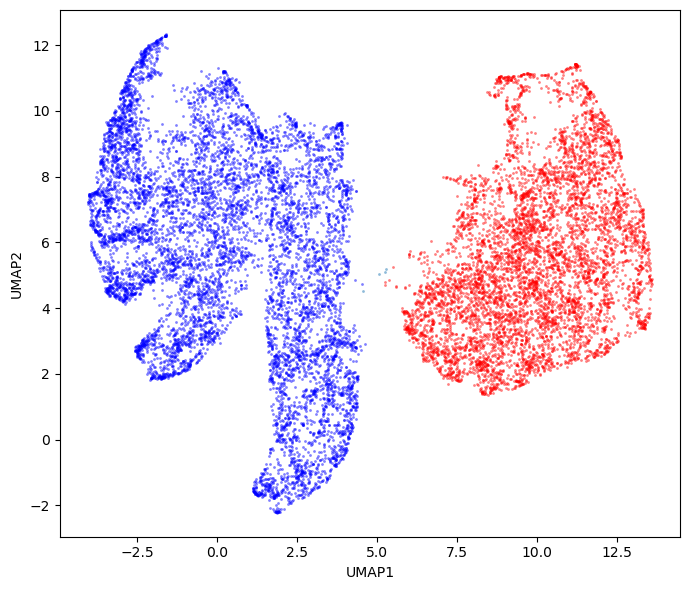

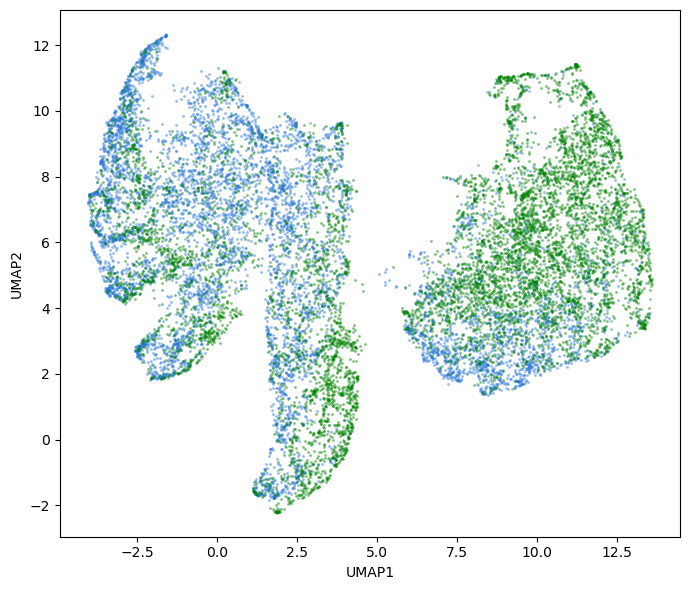

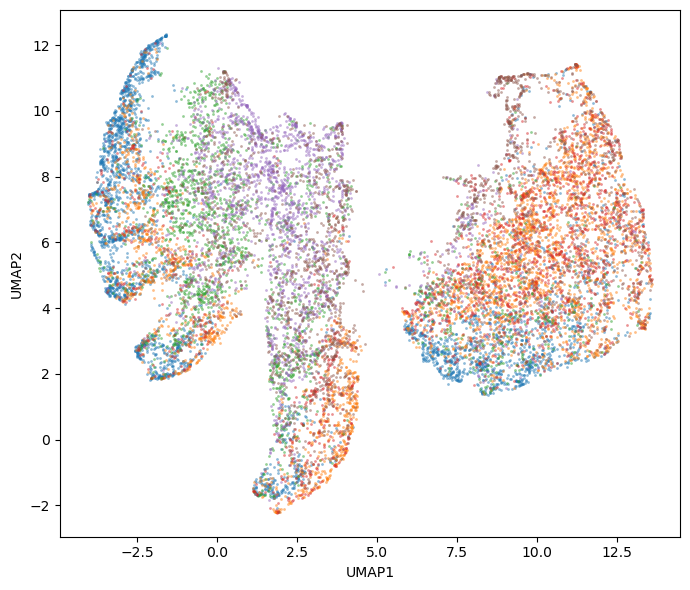

In [10]:
# ─── 8) SCATTERPLOTS (MATPLOTLIB) ────────────────────────────────────────────
POINT_SIZE = 4
POINT_ALPHA = 0.5
FALLBACK_CMAP = plt.get_cmap("tab10")
CLUSTER_COLORS = {"0": "red", "1": "blue"}
SAVE_KW = dict(dpi=300, bbox_inches="tight")

def get_cluster_color(label, i):
    return CLUSTER_COLORS.get(label, FALLBACK_CMAP(i % FALLBACK_CMAP.N))

def _display(value, mapper):
    """Turn a raw data value into a display string. `mapper` may be None
    (use the value as-is), a dict, a callable, or a "{}"-style format string."""
    if mapper is None:
        return str(value)
    if callable(mapper):
        return mapper(value)
    if isinstance(mapper, dict):
        return mapper.get(value, str(value))
    return mapper.format(value)

def format_condition_display(cond):
    """Turn a raw condition string ('30um|N' or '30um') into a display label
    ('30 µm | -Mac' or '30 µm')."""
    s = re.sub(r"(\d+)\s*um", r"\1 µm", cond)
    return s.replace("|Y", " | +Mac").replace("|N", " | -Mac")

def save_legend(handles, outdir, filename_stem, title=None, ncol=1):
    """Save a legend as its own tightly-cropped PNG/PDF, separate from the plot
    it came from -- for figures assembled/laid out later (e.g. in Illustrator)."""
    outdir.mkdir(exist_ok=True, parents=True)
    fig_leg = plt.figure(figsize=(4, 4))
    legend = fig_leg.legend(handles=handles, title=title, loc="center", frameon=False, ncol=ncol)
    fig_leg.canvas.draw()
    bbox = legend.get_window_extent().transformed(fig_leg.dpi_scale_trans.inverted())
    fig_leg.savefig(outdir / f"{filename_stem}.png", dpi=300, bbox_inches=bbox, pad_inches=0.05)
    fig_leg.savefig(outdir / f"{filename_stem}.pdf", bbox_inches=bbox, pad_inches=0.05)
    plt.close(fig_leg)

def plot_umap_by_cluster(emb_df, outdir, filename_stem):
    outdir.mkdir(exist_ok=True, parents=True)
    clusters = emb_df["cluster"].astype(str)
    cluster_labels = np.sort(clusters.unique())
    fig, ax = plt.subplots(figsize=(7, 6))
    for i, lab in enumerate(cluster_labels):
        m = (clusters == lab).to_numpy()
        ax.scatter(emb_df.loc[m, "UMAP1"], emb_df.loc[m, "UMAP2"], s=POINT_SIZE, alpha=POINT_ALPHA,
                   c=[get_cluster_color(lab, i)], linewidths=0)
    handles = [Line2D([0], [0], marker="o", linestyle="", markerfacecolor=get_cluster_color(lab, i),
                       markeredgewidth=0, markersize=8, label=f"Cluster {lab}")
               for i, lab in enumerate(cluster_labels)]
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    fig.tight_layout()
    fig.savefig(outdir / f"{filename_stem}.png", **SAVE_KW)
    fig.savefig(outdir / f"{filename_stem}.pdf", bbox_inches="tight")
    plt.show()
    save_legend(handles, outdir, f"{filename_stem}_legend", title="Cluster")

def plot_umap_by_label(emb_df, label_col, outdir, filename_stem, palette=None, label_map=None):
    outdir.mkdir(exist_ok=True, parents=True)
    labs = emb_df[label_col].astype(str)
    lab_values = np.sort(labs.unique())
    cmap = plt.get_cmap("tab10")
    colors = palette or {lab: cmap(i % cmap.N) for i, lab in enumerate(lab_values)}
    fig, ax = plt.subplots(figsize=(7, 6))
    for lab in lab_values:
        m = (labs == lab).to_numpy()
        ax.scatter(emb_df.loc[m, "UMAP1"], emb_df.loc[m, "UMAP2"], s=POINT_SIZE, alpha=POINT_ALPHA,
                   c=[colors[lab]], linewidths=0)
    handles = [Line2D([0], [0], marker="o", linestyle="", markerfacecolor=colors[lab],
                       markeredgewidth=0, markersize=8, label=_display(lab, label_map))
               for lab in lab_values]
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    fig.tight_layout()
    fig.savefig(outdir / f"{filename_stem}.png", **SAVE_KW)
    fig.savefig(outdir / f"{filename_stem}.pdf", bbox_inches="tight")
    plt.show()
    save_legend(handles, outdir, f"{filename_stem}_legend", title=label_col)

plot_umap_by_cluster(bcell_emb, BCELL_OUTDIR, "bcell_umap_by_cluster")
plot_umap_by_label(bcell_emb, "mac", BCELL_OUTDIR, "bcell_umap_by_mac",
                    palette={"N": "#2a78d6", "Y": "#008300"}, label_map={"N": "-Mac", "Y": "+Mac"})
plot_umap_by_label(bcell_emb, "condition", BCELL_OUTDIR, "bcell_umap_by_condition",
                    label_map=format_condition_display)


## 8b. Faceted scatterplots by condition
UMAP embedding colored by HDBSCAN cluster, faceted into the 6 (size, macrophage-presence) conditions.

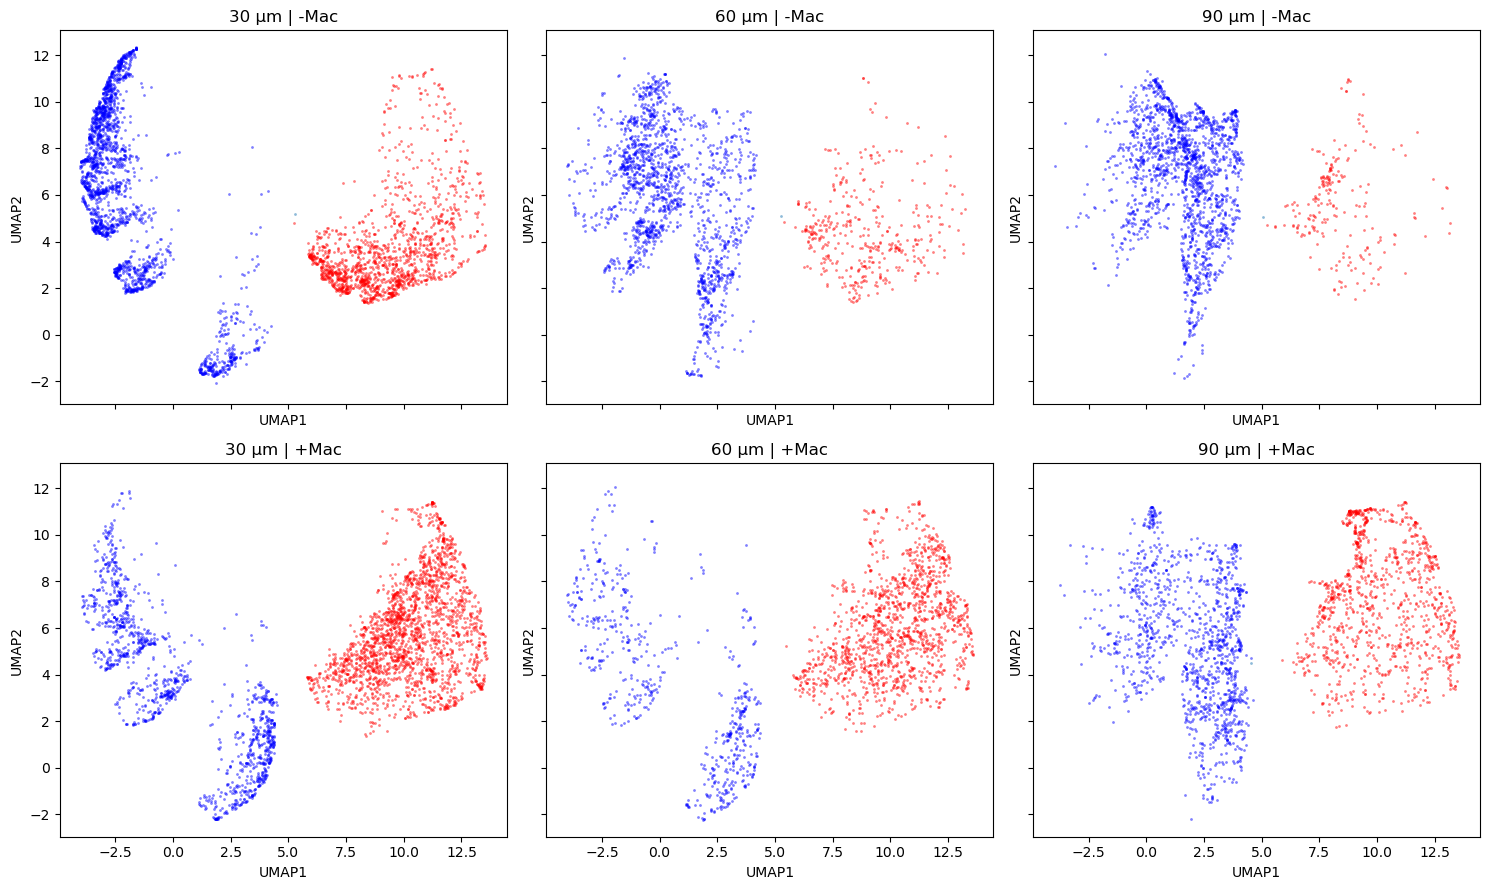

In [11]:
# ─── 8b) FACETED SCATTERPLOTS BY CONDITION ───────────────────────────────────
def _draw_condition_panel(ax, emb_df, clusters, cluster_labels, cond):
    """Draw one condition's points (colored by cluster) onto `ax`. Returns False
    (and blanks the axis) if this condition has no data."""
    mcond = (emb_df["condition"] == cond).to_numpy()
    if not np.any(mcond):
        ax.axis("off")
        return False
    for i, lab in enumerate(cluster_labels):
        m = mcond & (clusters == lab).to_numpy()
        if not np.any(m):
            continue
        ax.scatter(emb_df.loc[m, "UMAP1"], emb_df.loc[m, "UMAP2"], s=POINT_SIZE, alpha=POINT_ALPHA,
                   c=[get_cluster_color(lab, i)], linewidths=0)
    ax.set_title(format_condition_display(cond))
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    return True

def plot_umap_by_cluster_faceted(emb_df, condition_order, outdir, filename_stem, ncols=3):
    """Saves the combined multi-panel overview figure, its legend, AND each
    condition's panel as its own standalone file (for laying out separately,
    e.g. in Illustrator)."""
    outdir.mkdir(exist_ok=True, parents=True)
    clusters = emb_df["cluster"].astype(str)
    cluster_labels = np.sort(clusters.unique())

    n = len(condition_order)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4.5 * nrows),
                              sharex=True, sharey=True)
    axes = np.atleast_2d(axes)

    for idx in range(nrows * ncols):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]
        if idx >= n:
            ax.axis("off")
            continue
        _draw_condition_panel(ax, emb_df, clusters, cluster_labels, condition_order[idx])

    handles = [Line2D([0], [0], marker="o", linestyle="", markerfacecolor=get_cluster_color(lab, i),
                       markeredgewidth=0, markersize=8, label=f"Cluster {lab}")
               for i, lab in enumerate(cluster_labels)]
    fig.tight_layout()
    fig.savefig(outdir / f"{filename_stem}.png", **SAVE_KW)
    fig.savefig(outdir / f"{filename_stem}.pdf", bbox_inches="tight")
    plt.show()
    save_legend(handles, outdir, f"{filename_stem}_legend", title="Cluster")

    for cond in condition_order:
        slug = re.sub(r"[^\w\-]+", "_", cond).strip("_")
        fig_i, ax_i = plt.subplots(figsize=(5, 4.5))
        drawn = _draw_condition_panel(ax_i, emb_df, clusters, cluster_labels, cond)
        if drawn:
            fig_i.tight_layout()
            fig_i.savefig(outdir / f"{filename_stem}_{slug}.png", **SAVE_KW)
            fig_i.savefig(outdir / f"{filename_stem}_{slug}.pdf", bbox_inches="tight")
        plt.close(fig_i)

plot_umap_by_cluster_faceted(
    bcell_emb,
    condition_order=["30um|N", "60um|N", "90um|N", "30um|Y", "60um|Y", "90um|Y"],
    outdir=BCELL_OUTDIR,
    filename_stem="bcell_umap_by_cluster_faceted",
    ncols=3
)


## 9. Cluster composition by condition
For each well size, the % of B cell tracks in each cluster, split by Without (N) vs With (Y)
macrophages. `plot_cluster_composition` (Section 9 code cell) is a generic stacked-bar helper
also used, unmodified, by the macrophage notebook.

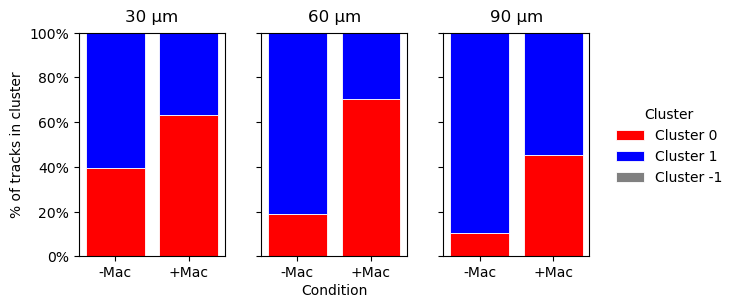

In [12]:
# ─── 9) CLUSTER COMPOSITION BAR CHART ────────────────────────────────────────
def build_cluster_colors(emb_df):
    """Cluster 0 = red, Cluster 1 = blue, noise (-1) = grey; any other cluster
    gets a color from Plotly's qualitative palette."""
    cluster_labels = sorted(emb_df["cluster"].astype(str).unique())
    plotly_palette = px.colors.qualitative.Plotly
    colors = {cl: plotly_palette[i % len(plotly_palette)] for i, cl in enumerate(cluster_labels)}
    colors["0"] = "red"
    colors["1"] = "blue"
    colors["-1"] = "grey"
    return colors

DEFAULT_CLUSTER_COLOR = "grey"

def plot_cluster_composition(emb_df, bar_col, outdir, filename_stem, panel_col=None,
                              panel_order=None, bar_order=None, panel_label_fmt="{}",
                              bar_label_fmt="{}", xlabel="Condition"):
    """Stacked bar chart of the % of tracks in each cluster. `bar_col` sets the
    x-axis categories within a panel; `panel_col` (optional) splits the figure
    into side-by-side panels, e.g. one per well size. `panel_label_fmt` /
    `bar_label_fmt` may be a "{}"-style format string, a dict, or a callable."""
    outdir.mkdir(exist_ok=True, parents=True)
    df = emb_df.copy()
    df["cluster_str"] = df["cluster"].astype(str)
    cluster_colors = build_cluster_colors(df)

    bar_labels = bar_order or sorted(df[bar_col].unique())
    panels = (panel_order or sorted(df[panel_col].unique())) if panel_col else [None]

    if panel_col:
        counts = pd.crosstab([df[panel_col], df[bar_col]], df["cluster_str"])
    else:
        counts = pd.crosstab(df[bar_col], df["cluster_str"])
    props = counts.div(counts.sum(axis=1), axis=0).fillna(0)

    cluster_order = list(props.columns)
    if "-1" in cluster_order:
        cluster_order = [c for c in cluster_order if c != "-1"] + ["-1"]
    props = props[cluster_order]

    fig = plt.figure(figsize=(180 / 25.4, 80 / 25.4))
    axes = fig.subplots(1, len(panels), sharey=True)
    axes = np.atleast_1d(axes)

    x = np.arange(len(bar_labels))
    for ax, panel in zip(axes, panels):
        if panel_col:
            idx = pd.MultiIndex.from_product([[panel], bar_labels])
            sub = props.reindex(idx).fillna(0)
        else:
            sub = props.reindex(bar_labels).fillna(0)

        bottom = np.zeros(len(bar_labels))
        for cl in cluster_order:
            vals = sub[cl].values
            ax.bar(x, vals, bottom=bottom, label=f"Cluster {cl}",
                   color=cluster_colors.get(cl, DEFAULT_CLUSTER_COLOR),
                   edgecolor="white", linewidth=0.6)
            bottom += vals

        if panel is not None:
            ax.set_title(_display(panel, panel_label_fmt), pad=8)
        ax.set_xticks(x)
        ax.set_xticklabels([_display(b, bar_label_fmt) for b in bar_labels])
        ax.set_ylim(0, 1.0)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

    axes[0].set_ylabel("% of tracks in cluster")
    fig.subplots_adjust(left=0.08, right=0.80, top=0.86, bottom=0.15, wspace=0.25)
    fig.text((0.08 + 0.80) / 2, 0.04, xlabel, ha="center", va="center")

    handles, labels = axes[-1].get_legend_handles_labels()
    seen = set(); handles2 = []; labels2 = []
    for h, l in zip(handles, labels):
        if l not in seen:
            handles2.append(h); labels2.append(l); seen.add(l)
    fig.legend(handles2, labels2, title="Cluster", loc="center left", bbox_to_anchor=(0.82, 0.5), frameon=False)

    plt.rcParams["pdf.fonttype"] = 42
    plt.rcParams["ps.fonttype"] = 42
    fig.savefig(outdir / f"{filename_stem}.pdf")
    fig.savefig(outdir / f"{filename_stem}.png", dpi=300)
    plt.show()

bcell_plot_df = bcell_emb.copy()
bcell_plot_df["size_um"] = bcell_plot_df["size_um"].astype(int)

plot_cluster_composition(
    bcell_plot_df,
    bar_col="mac", bar_order=["N", "Y"], bar_label_fmt={"N": "-Mac", "Y": "+Mac"},
    panel_col="size_um", panel_order=[30, 60, 90], panel_label_fmt="{} µm",
    outdir=BCELL_OUTDIR, filename_stem="bcell_cluster_composition",
    xlabel="Condition"
)


## 10. Random Forest + SHAP
Trains a Random Forest to predict the pooled B-cell cluster label from z-scored features,
reports CV accuracy, and computes SHAP per cluster. Figures are saved to this run's output
folder under `Final Analysis Outputs/Bcells`.


Bcells_pooled_WithAndWithoutMacrophages
Rows: 15634 | Non-noise: 15630 | Noise: 4
Clusters (non-noise): [np.int64(0), np.int64(1)]
0    6747
1    8883


[CV] RF accuracy: 0.995 +/- 0.002 (n_splits=5)


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


,feature,importance
0,TRACK_DURATION,0.451486
1,NUMBER_SPOTS,0.316187
2,TOTAL_DISTANCE_TRAVELED,0.106937
3,CONFINEMENT_RATIO,0.050726
4,NUMBER_SPLITS,0.029538
5,TRACK_MEDIAN_SPEED,0.017149
6,TRACK_DISPLACEMENT,0.014480
7,MEAN_DIRECTIONAL_CHANGE_RATE,0.013497


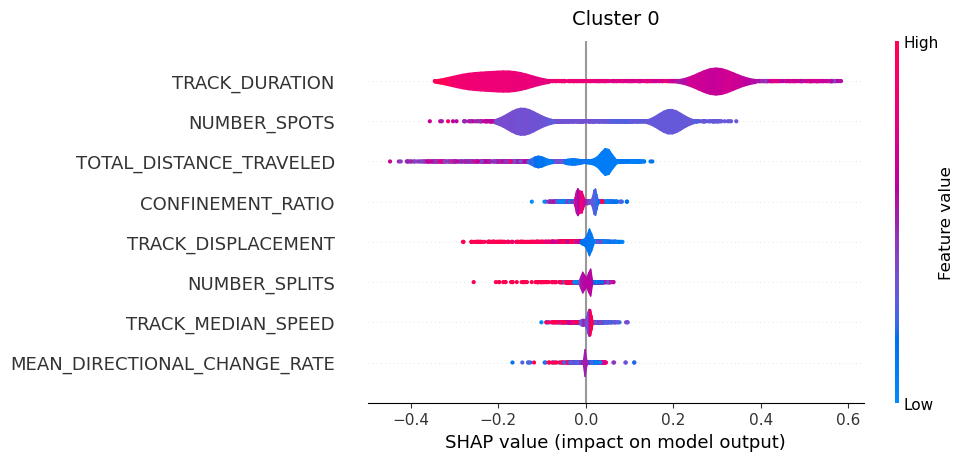

,cluster,feature,mean_abs_SHAP
0,0,TRACK_DURATION,0.249353
1,0,NUMBER_SPOTS,0.162458
2,0,TOTAL_DISTANCE_TRAVELED,0.060238
3,0,CONFINEMENT_RATIO,0.016939
4,0,TRACK_DISPLACEMENT,0.011858
5,0,NUMBER_SPLITS,0.010285
6,0,TRACK_MEDIAN_SPEED,0.008743
7,0,MEAN_DIRECTIONAL_CHANGE_RATE,0.004607


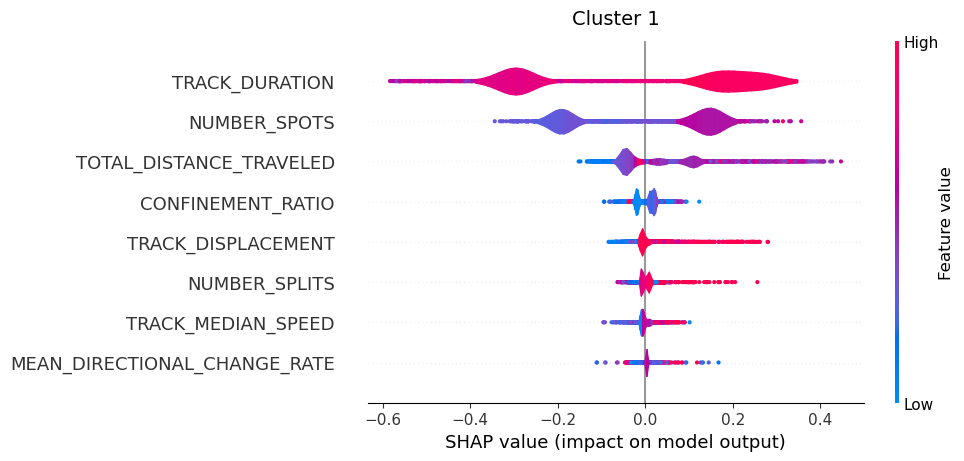

,cluster,feature,mean_abs_SHAP
0,1,TRACK_DURATION,0.249353
1,1,NUMBER_SPOTS,0.162458
2,1,TOTAL_DISTANCE_TRAVELED,0.060238
3,1,CONFINEMENT_RATIO,0.016939
4,1,TRACK_DISPLACEMENT,0.011858
5,1,NUMBER_SPLITS,0.010285
6,1,TRACK_MEDIAN_SPEED,0.008743
7,1,MEAN_DIRECTIONAL_CHANGE_RATE,0.004607


,cluster,feature,mean_abs_SHAP
0,0,TRACK_DURATION,0.249353
1,0,NUMBER_SPOTS,0.162458
2,0,TOTAL_DISTANCE_TRAVELED,0.060238
3,0,CONFINEMENT_RATIO,0.016939
4,0,TRACK_DISPLACEMENT,0.011858
5,0,NUMBER_SPLITS,0.010285
6,0,TRACK_MEDIAN_SPEED,0.008743
7,0,MEAN_DIRECTIONAL_CHANGE_RATE,0.004607
8,1,TRACK_DURATION,0.249353
9,1,NUMBER_SPOTS,0.162458



Saved PNGs to: ./Final Analysis Outputs/Bcells/20260813_trial2


In [13]:
# ─── 10) Random Forest + SHAP -- B CELLS ────────────────────────────────────
def _safe(s: str) -> str:
    return re.sub(r"[^\w\-]+", "_", str(s)).strip("_")[:160]

def save_df_as_png(df, filepath, max_rows=25, fontsize=10):
    df_show = df.head(max_rows).copy()
    fig_h = max(2.0, 0.35 * len(df_show) + 1.2)
    fig, ax = plt.subplots(figsize=(12, fig_h))
    ax.axis("off")
    tbl = ax.table(cellText=df_show.values, colLabels=df_show.columns, cellLoc="center", loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.scale(1, 1.25)
    plt.tight_layout()
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

def _coi_explanation_for_class(shap_values, coi_idx):
    if hasattr(shap_values, "values"):
        if shap_values.values.ndim == 3:
            return shap.Explanation(
                values=shap_values.values[:, :, coi_idx],
                base_values=np.array(shap_values.base_values)[:, coi_idx],
                data=shap_values.data,
                feature_names=shap_values.feature_names
            )
        else:
            return shap_values
    else:
        return shap_values[coi_idx]

def explain_clusters_shap_and_export(model, X_eval, y_clusters, feat_names, outdir, run_tag, max_display=20):
    if len(np.unique(y_clusters)) < 2:
        print("[WARN] < 2 classes in y_clusters; SHAP per-class view not meaningful.")
        return None

    X_for_shap = pd.DataFrame(X_eval, columns=feat_names)
    le = LabelEncoder()
    le.fit_transform(y_clusters)
    raw_classes = sorted(np.unique(y_clusters))

    outdir.mkdir(exist_ok=True, parents=True)
    run_tag = _safe(run_tag)

    explainer = shap.TreeExplainer(model, model_output="raw")
    shap_values = explainer(X_for_shap)

    tables = []
    for COI in raw_classes:
        encoded_label = le.transform([COI])[0]
        coi_idx_arr = np.where(model.classes_ == encoded_label)[0]
        if len(coi_idx_arr) == 0:
            continue
        coi_idx = coi_idx_arr[0]
        coi_shap = _coi_explanation_for_class(shap_values, coi_idx)
        vals = getattr(coi_shap, "values", coi_shap)

        plt.figure(figsize=(10, 6))
        try:
            shap.plots.violin(coi_shap, max_display=max_display, show=False)
        except Exception:
            shap.summary_plot(vals, X_eval, feature_names=feat_names, plot_type="violin",
                               max_display=max_display, show=False)
        plt.title(f"Cluster {COI}", fontsize=14, pad=12)
        plt.savefig(outdir / f"{run_tag}_cluster_{COI}_SHAP_violin.png", dpi=300, bbox_inches="tight")
        plt.show()

        mean_abs = np.abs(vals).mean(axis=0)
        df_imp = (pd.DataFrame({"feature": feat_names, "mean_abs_SHAP": mean_abs})
                    .sort_values("mean_abs_SHAP", ascending=False).reset_index(drop=True))
        df_imp.insert(0, "cluster", COI)
        tables.append(df_imp)
        save_df_as_png(df_imp, outdir / f"{run_tag}_cluster_{COI}_SHAP_table.png", max_rows=max_display)
        display(df_imp.head(max_display))

    if tables:
        all_tbl = pd.concat(tables, ignore_index=True)
        save_df_as_png(all_tbl, outdir / f"{run_tag}_SHAP_all_clusters_table.png", max_rows=40)
        display(all_tbl.head(40))
        return all_tbl
    return None

def run_rf_shap(X_df, y_labels, feat_cols, title, outdir):
    """RF + SHAP for predicting cluster label from z-scored features."""
    outdir.mkdir(exist_ok=True, parents=True)
    title_safe = _safe(title)

    mask = (y_labels != -1)
    X_keep = X_df.loc[mask].copy()
    y_keep = y_labels[mask]

    print("\n" + "=" * 100)
    print(title)
    print(f"Rows: {len(y_labels)} | Non-noise: {len(y_keep)} | Noise: {len(y_labels) - len(y_keep)}")
    print("Clusters (non-noise):", sorted(pd.unique(y_keep)))
    print(pd.Series(y_keep).value_counts().sort_index().to_string())
    print("=" * 100)

    if len(np.unique(y_keep)) < 2:
        print("[WARN] < 2 non-noise clusters; RF classification not meaningful.")
        return None, None, None

    scaler = StandardScaler(with_mean=True, with_std=True)
    Xz = scaler.fit_transform(X_keep.values)

    rf = RandomForestClassifier(**RF_PARAMS)
    n_splits = 5 if len(y_keep) >= 50 and all((y_keep == k).sum() >= 5 for k in np.unique(y_keep)) else 3
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = cross_val_score(rf, Xz, y_keep, cv=cv, scoring="accuracy", n_jobs=-1)
    print(f"[CV] RF accuracy: {scores.mean():.3f} +/- {scores.std():.3f} (n_splits={n_splits})")

    rf.fit(Xz, y_keep)
    fi = (pd.DataFrame({"feature": feat_cols, "importance": rf.feature_importances_})
            .sort_values("importance", ascending=False).reset_index(drop=True))

    fig_b = px.bar(fi, x="feature", y="importance")
    fig_b.update_layout(xaxis_tickangle=-30)
    fig_b.show()
    fig_b.write_image(outdir / f"{title_safe}_RF_feature_importance.png")
    save_df_as_png(fi, outdir / f"{title_safe}_RF_feature_importance_table.png", max_rows=25)
    display(fi.head(25))

    shap_tbl = explain_clusters_shap_and_export(rf, Xz, y_keep, feat_cols, outdir, title_safe)
    return rf, fi, shap_tbl

rf_bcell, fi_bcell, shap_bcell = run_rf_shap(
    X_df=X_bcell, y_labels=labels_bcell, feat_cols=feat_cols,
    title="Bcells_pooled_WithAndWithoutMacrophages", outdir=BCELL_OUTDIR
)
print(f"\nSaved PNGs to: ./{BCELL_OUTDIR.relative_to(BASE_DIR)}")
